<a href="https://colab.research.google.com/github/amodita-a/sea-ad-microglia-analysis/blob/main/notebooks/01_sea_ad_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Microglial immune programs across Alzheimer's disease pathology

This notebook is an independent educational reanalysis of publicly available Seattle Alzheimer's Disease Brain Cell Atlas (SEA-AD) single-nucleus RNA-sequencing data. It asks whether two **prespecified exploratory gene sets**—interferon response and antigen presentation—show different donor-level mean normalized expression across Alzheimer's disease neuropathology.

The unit of statistical analysis is the **donor**, not the individual nucleus. Results are exploratory, observational, and non-causal.


In [1]:
# Colab setup: install the Census client version compatible with the pinned LTS release.
%pip install -q "cellxgene-census==1.17.0" "openpyxl==3.1.5" "statsmodels==0.14.6"

from io import BytesIO
from pathlib import Path
import hashlib
import platform
import warnings

import cellxgene_census
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scipy
from anndata import ImplicitModificationWarning
from scipy.stats import fisher_exact, mannwhitneyu, skew, spearmanr
import statsmodels
import statsmodels.formula.api as smf
from IPython.display import display

print("Python:", platform.python_version())
print("cellxgene-census:", cellxgene_census.__version__)
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)


In [2]:
# Reproducibility constants and output locations
CENSUS_VERSION = "2025-11-08"
MICROGLIA_MTG_DATASET_ID = "c76098ba-eed3-45b1-98f2-96fcac55ed18"
RANDOM_SEED = 20260817
MIN_NUCLEI_SENSITIVITY = 200

SEA_AD_DATA_PAGE = "https://brain-map.org/consortia/sea-ad/our-data"
DONOR_METADATA_URL = (
    "https://cdn.prod.website-files.com/689cfbd308fa7373b604d290/"
    "68debdfdd1b8e9f8fd64dab0_sea-ad_cohort_donor_metadata_072524.xlsx"
)
DONOR_METADATA_SHA256 = "d18faa1c51f426bb2bf17ce431878cfacce673729c1ee185be84a51d31271146"

OUTPUT_ROOT = Path("sea_ad_outputs")
FIGURE_DIR = OUTPUT_ROOT / "figures"
RESULTS_DIR = OUTPUT_ROOT / "results"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Pinned Census release:", CENSUS_VERSION)
print("Dataset ID:", MICROGLIA_MTG_DATASET_ID)
print("Runtime outputs:", OUTPUT_ROOT)


Pinned Census release: 2025-11-08
Dataset ID: c76098ba-eed3-45b1-98f2-96fcac55ed18
Runtime outputs: sea_ad_outputs


## Data sources and reproducibility

- The Census is pinned to the long-term-supported release [`2025-11-08`](https://chanzuckerberg.github.io/cellxgene-census/cellxgene_census_docsite_data_release_info.html).
- The SEA-AD Microglia-PVM middle temporal gyrus dataset is fixed by its Census dataset ID.
- Donor neuropathology metadata are downloaded programmatically from the official [SEA-AD data and downloads page](https://brain-map.org/consortia/sea-ad/our-data). A SHA-256 checksum prevents a changed file from being used silently.
- Generated files are written to `sea_ad_outputs/figures/` and `sea_ad_outputs/results/` in the current runtime. In Colab, this folder appears in the Files pane and can be downloaded.


In [3]:
# Open the pinned Census release and confirm the target dataset.
census = cellxgene_census.open_soma(census_version=CENSUS_VERSION)

datasets = census["census_info"]["datasets"].read().concat().to_pandas()
target_dataset = datasets.loc[
    datasets["dataset_id"] == MICROGLIA_MTG_DATASET_ID,
    ["collection_name", "dataset_title", "dataset_id", "dataset_total_cell_count"],
]

if len(target_dataset) != 1:
    raise RuntimeError(
        f"Expected exactly one dataset for {MICROGLIA_MTG_DATASET_ID}; found {len(target_dataset)}."
    )

display(target_dataset)


,collection_name,dataset_title,dataset_id,dataset_total_cell_count
1200,SEA-AD: Seattle Alzheimer’s Disease Brain Cell...,Microglia-PVM - MTG: Seattle Alzheimer's Disea...,c76098ba-eed3-45b1-98f2-96fcac55ed18,40000


## CELLxGENE metadata exploration

The first query retrieves observation metadata only. Counts are displayed after conversion to ordinary strings so unused categorical levels do not appear. A one-row-per-donor table excludes assay because some donors contribute nuclei from more than one assay.


In [4]:
obs_columns = [
    "donor_id", "disease", "sex", "assay", "tissue", "cell_type", "dataset_id"
]

microglia_meta = cellxgene_census.get_obs(
    census,
    "Homo sapiens",
    value_filter=f"dataset_id == '{MICROGLIA_MTG_DATASET_ID}'",
    column_names=obs_columns,
)

for column in ["donor_id", "disease", "sex", "assay", "tissue", "cell_type"]:
    microglia_meta[column] = microglia_meta[column].astype(str)

print("Nuclei in target dataset:", len(microglia_meta))
print("Unique CELLxGENE donors:", microglia_meta["donor_id"].nunique())

for column in ["cell_type", "disease", "sex", "assay", "tissue"]:
    print(f"\n{column}:")
    print(microglia_meta[column].value_counts())

disease_labels_per_donor = microglia_meta.groupby("donor_id")["disease"].nunique()
print("\nDisease-label counts per donor:")
print(disease_labels_per_donor.value_counts().sort_index())
assert disease_labels_per_donor.eq(1).all(), "At least one donor has multiple disease labels."


Nuclei in target dataset: 40000
Unique CELLxGENE donors: 89

cell_type:
cell_type
microglial cell    40000
Name: count, dtype: int64

disease:
disease
normal      20124
dementia    19876
Name: count, dtype: int64

sex:
sex
female    23249
male      16751
Name: count, dtype: int64

assay:
assay
10x 3' v3       35889
10x multiome     4111
Name: count, dtype: int64

tissue:
tissue
middle temporal gyrus    40000
Name: count, dtype: int64

Disease-label counts per donor:
disease
1    89
Name: count, dtype: int64


In [5]:
# Correct one-row-per-donor metadata table (89 donors; assay is summarized separately).
donor_meta = (
    microglia_meta[["donor_id", "disease", "sex"]]
    .drop_duplicates()
    .sort_values("donor_id")
    .reset_index(drop=True)
)

if len(donor_meta) != 89:
    raise RuntimeError(f"Expected 89 CELLxGENE donors; found {len(donor_meta)}.")

nuclei_per_all_donor = (
    microglia_meta.groupby("donor_id").size().sort_values().rename("n_nuclei")
)
assay_nuclei_all = pd.crosstab(microglia_meta["donor_id"], microglia_meta["assay"])

print("One-row-per-donor table:", donor_meta.shape)
display(donor_meta.head())
print("\nLowest nuclei counts before pathology matching:")
display(nuclei_per_all_donor.head(12).to_frame())
print("\nNumber of assays represented per donor:")
print((assay_nuclei_all > 0).sum(axis=1).value_counts().sort_index())


One-row-per-donor table: (89, 3)


,donor_id,disease,sex
0,H18.30.001,normal,female
1,H18.30.002,normal,male
2,H19.30.001,normal,male
3,H19.30.002,normal,male
4,H19.33.004,normal,female



Lowest nuclei counts before pathology matching:


,n_nuclei
donor_id,
H18.30.001,1
H200.1023,1
H20.33.037,79
H21.33.020,118
H20.33.024,127
H18.30.002,156
H20.33.036,162
H21.33.038,165
H20.33.026,182



Number of assays represented per donor:
1    62
2    27
Name: count, dtype: int64


## Official SEA-AD donor metadata and donor matching

The official workbook is downloaded directly; no manual Colab upload is required. The expected relationship is 84 SEA-AD metadata donors matched to 89 CELLxGENE donors. Unmatched IDs are printed explicitly rather than silently dropped.


In [6]:
metadata_response = requests.get(DONOR_METADATA_URL, timeout=60)
metadata_response.raise_for_status()

downloaded_sha256 = hashlib.sha256(metadata_response.content).hexdigest()
if downloaded_sha256 != DONOR_METADATA_SHA256:
    raise RuntimeError(
        "The official donor metadata file checksum changed. Re-verify the file on the SEA-AD data page "
        "before continuing."
    )

seaad_donors = pd.read_excel(BytesIO(metadata_response.content), engine="openpyxl")
seaad_donors["Donor ID"] = seaad_donors["Donor ID"].astype(str)

if seaad_donors["Donor ID"].nunique() != 84:
    raise RuntimeError(
        f"Expected 84 unique official metadata donors; found {seaad_donors['Donor ID'].nunique()}."
    )

print("Official metadata rows:", len(seaad_donors))
print("Official unique donors:", seaad_donors["Donor ID"].nunique())
print("Verified SHA-256:", downloaded_sha256)


Official metadata rows: 84
Official unique donors: 84
Verified SHA-256: d18faa1c51f426bb2bf17ce431878cfacce673729c1ee185be84a51d31271146


In [7]:
cellxgene_ids = set(donor_meta["donor_id"])
seaad_ids = set(seaad_donors["Donor ID"])

matched_ids = cellxgene_ids & seaad_ids
cellxgene_unmatched = sorted(cellxgene_ids - seaad_ids)
metadata_unmatched = sorted(seaad_ids - cellxgene_ids)

print("CELLxGENE donors:", len(cellxgene_ids))
print("Official metadata donors:", len(seaad_ids))
print("Matched donors:", len(matched_ids))
print("CELLxGENE donors without matching official pathology metadata:", cellxgene_unmatched)
print("Official metadata donors absent from CELLxGENE:", metadata_unmatched)

expected_unmatched = ["H18.30.001", "H18.30.002", "H19.30.001", "H19.30.002", "H200.1023"]
if len(matched_ids) != 84 or cellxgene_unmatched != expected_unmatched or metadata_unmatched:
    raise RuntimeError("Donor matching differs from the verified 84-of-89 relationship.")

print("\nOne-nucleus donors in the full 89-donor dataset:")
print(nuclei_per_all_donor.loc[nuclei_per_all_donor == 1])


CELLxGENE donors: 89
Official metadata donors: 84
Matched donors: 84
CELLxGENE donors without matching official pathology metadata: ['H18.30.001', 'H18.30.002', 'H19.30.001', 'H19.30.002', 'H200.1023']
Official metadata donors absent from CELLxGENE: []

One-nucleus donors in the full 89-donor dataset:
donor_id
H18.30.001    1
H200.1023     1
Name: n_nuclei, dtype: int64


In [8]:
analysis_meta = donor_meta.merge(
    seaad_donors,
    left_on="donor_id",
    right_on="Donor ID",
    how="left",
)
analysis_meta = analysis_meta.loc[
    analysis_meta["Overall AD neuropathological Change"].notna()
].copy()

# Analyst-defined exploratory dichotomy; the four-level ADNC variable is retained below.
pathology_map = {
    "Not AD": "Lower pathology",
    "Low": "Lower pathology",
    "Intermediate": "Higher pathology",
    "High": "Higher pathology",
}
adnc_map = {"Not AD": 0, "Low": 1, "Intermediate": 2, "High": 3}

analysis_meta["pathology_group"] = analysis_meta[
    "Overall AD neuropathological Change"
].map(pathology_map)
analysis_meta["adnc_numeric"] = analysis_meta[
    "Overall AD neuropathological Change"
].map(adnc_map)

if analysis_meta["pathology_group"].isna().any():
    raise RuntimeError("Unexpected or missing ADNC category encountered.")

print("Analytic donors:", len(analysis_meta))
print("\nFour-level ADNC counts:")
print(analysis_meta["Overall AD neuropathological Change"].value_counts())
print("\nExploratory binary grouping:")
print(analysis_meta["pathology_group"].value_counts())
display(
    pd.crosstab(
        analysis_meta["pathology_group"],
        analysis_meta["Overall AD neuropathological Change"],
    )
)


Analytic donors: 84

Four-level ADNC counts:
Overall AD neuropathological Change
High            42
Intermediate    21
Low             12
Not AD           9
Name: count, dtype: int64

Exploratory binary grouping:
pathology_group
Higher pathology    63
Lower pathology     21
Name: count, dtype: int64


Overall AD neuropathological Change,High,Intermediate,Low,Not AD
pathology_group,,,,
Higher pathology,42,21,0,0
Lower pathology,0,0,12,9


## Prespecified exploratory gene sets

These compact gene sets were selected before the final comparisons to represent recognizable biology while keeping the educational analysis tractable:

- The interferon set contains canonical interferon-stimulated genes and overlaps the [MSigDB Hallmark interferon-alpha response](https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_INTERFERON_ALPHA_RESPONSE.html) and interferon-gamma response collections.
- The antigen-presentation set focuses on MHC class II chains, the invariant-chain gene `CD74`, and the MHC class II transactivator `CIITA`, consistent with the [Reactome MHC class II antigen-presentation pathway](https://reactome.org/content/detail/R-HSA-2132295).

The resulting values are **mean normalized gene-set expression**. They are not validated biomarkers, formal enrichment scores, or background-corrected module scores, and these small lists are not claimed to reproduce the complete reference pathways.


In [9]:
interferon_genes = [
    "IFI6", "IFI27", "IFI44", "IFI44L", "IFIT1", "IFIT2", "IFIT3",
    "ISG15", "MX1", "OAS1", "OAS2", "STAT1",
]

antigen_presentation_genes = [
    "HLA-DRA", "HLA-DRB1", "HLA-DPA1", "HLA-DPB1", "HLA-DQA1",
    "HLA-DQB1", "CD74", "CIITA",
]

requested_genes = interferon_genes + antigen_presentation_genes
print("Requested genes:", len(requested_genes))


Requested genes: 20


## Retrieve normalized expression and calculate donor-level values

Only the target dataset and 20 requested genes are retrieved from the Census `normalized` layer. The code fails clearly if a gene is absent or a requested symbol is duplicated in this release.


In [10]:
gene_filter = "feature_name in [" + ", ".join(repr(gene) for gene in requested_genes) + "]"

with warnings.catch_warnings():
    # AnnData coerces Census join-ID indices to strings; this expected conversion is benign.
    warnings.simplefilter("ignore", ImplicitModificationWarning)
    adata_norm = cellxgene_census.get_anndata(
        census=census,
        organism="Homo sapiens",
        X_name="normalized",
        obs_value_filter=f"dataset_id == '{MICROGLIA_MTG_DATASET_ID}'",
        var_value_filter=gene_filter,
        obs_column_names=["donor_id", "disease", "sex", "assay", "tissue"],
        var_column_names=["feature_id", "feature_name"],
    )

for column in ["donor_id", "disease", "sex", "assay", "tissue"]:
    adata_norm.obs[column] = adata_norm.obs[column].astype(str)

included_donors = set(analysis_meta["donor_id"])
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ImplicitModificationWarning)
    adata_norm = adata_norm[adata_norm.obs["donor_id"].isin(included_donors)].copy()

gene_symbol_counts = adata_norm.var["feature_name"].astype(str).value_counts()
missing_genes = [gene for gene in requested_genes if gene not in gene_symbol_counts.index]
duplicated_requested_symbols = gene_symbol_counts.loc[gene_symbol_counts > 1].to_dict()

if missing_genes:
    raise RuntimeError(f"Requested genes missing from the pinned Census release: {missing_genes}")
if duplicated_requested_symbols:
    raise RuntimeError(
        f"Requested gene symbols are non-unique in the pinned release: {duplicated_requested_symbols}"
    )

print("Analytic nuclei:", adata_norm.n_obs)
print("Analytic donors:", adata_norm.obs["donor_id"].nunique())
print("Genes retrieved:", adata_norm.n_vars)
print("All 20 requested genes were found exactly once.")


Analytic nuclei: 38905
Analytic donors: 84
Genes retrieved: 20
All 20 requested genes were found exactly once.


In [11]:
def row_mean(matrix, positions):
    # Mean expression across selected columns for each row, sparse or dense.
    return np.asarray(matrix[:, positions].mean(axis=1)).ravel()


feature_positions = {
    symbol: position
    for position, symbol in enumerate(adata_norm.var["feature_name"].astype(str))
}

obs_scores = adata_norm.obs.copy()
obs_scores["interferon_score"] = row_mean(
    adata_norm.X, [feature_positions[gene] for gene in interferon_genes]
)
obs_scores["antigen_presentation_score"] = row_mean(
    adata_norm.X, [feature_positions[gene] for gene in antigen_presentation_genes]
)

print("Nucleus-level interferon mean normalized gene-set expression:")
display(obs_scores["interferon_score"].describe().to_frame().T)
print("Nucleus-level antigen-presentation mean normalized gene-set expression:")
display(obs_scores["antigen_presentation_score"].describe().to_frame().T)


Nucleus-level interferon mean normalized gene-set expression:


,count,mean,std,min,25%,50%,75%,max
interferon_score,38905.0,0.000032,0.000051,0.0,0.0,0.000017,0.00004,0.001521


Nucleus-level antigen-presentation mean normalized gene-set expression:


,count,mean,std,min,25%,50%,75%,max
antigen_presentation_score,38905.0,0.000191,0.00017,0.0,0.000079,0.000153,0.000255,0.003486


In [12]:
# Average nucleus-level values within donor: donors are the independent observations.
donor_scores = (
    obs_scores.groupby("donor_id")[["interferon_score", "antigen_presentation_score"]]
    .mean()
    .reset_index()
)
nuclei_per_donor = obs_scores.groupby("donor_id").size().rename("n_nuclei")
assay_nuclei = pd.crosstab(obs_scores["donor_id"], obs_scores["assay"])

donor_results = donor_scores.merge(
    analysis_meta[
        [
            "donor_id", "pathology_group", "Overall AD neuropathological Change",
            "adnc_numeric", "Age at Death", "sex",
        ]
    ],
    on="donor_id",
    how="inner",
).merge(nuclei_per_donor.reset_index(), on="donor_id", how="left")

for assay_name in ["10x 3' v3", "10x multiome"]:
    if assay_name not in assay_nuclei.columns:
        assay_nuclei[assay_name] = 0

assay_metrics = pd.DataFrame(
    {
        "donor_id": assay_nuclei.index,
        "nuclei_10x_3prime_v3": assay_nuclei["10x 3' v3"].to_numpy(),
        "nuclei_10x_multiome": assay_nuclei["10x multiome"].to_numpy(),
    }
)
assay_metrics["multiome_fraction"] = (
    assay_metrics["nuclei_10x_multiome"]
    / (assay_metrics["nuclei_10x_3prime_v3"] + assay_metrics["nuclei_10x_multiome"])
)

donor_results = donor_results.merge(assay_metrics, on="donor_id", how="left")
donor_results["higher_pathology"] = donor_results["pathology_group"].eq(
    "Higher pathology"
).astype(int)
donor_results["male"] = donor_results["sex"].str.lower().eq("male").astype(int)

if len(donor_results) != 84 or donor_results["donor_id"].nunique() != 84:
    raise RuntimeError("Donor-level aggregation did not produce exactly 84 unique donors.")

print("Donor-level rows:", len(donor_results))
print("Minimum/median/maximum nuclei per analytic donor:",
      donor_results["n_nuclei"].min(),
      donor_results["n_nuclei"].median(),
      donor_results["n_nuclei"].max())
display(donor_results.head())


Donor-level rows: 84
Minimum/median/maximum nuclei per analytic donor: 79 394.5 1077


,donor_id,interferon_score,antigen_presentation_score,pathology_group,Overall AD neuropathological Change,adnc_numeric,Age at Death,sex,n_nuclei,nuclei_10x_3prime_v3,nuclei_10x_multiome,multiome_fraction,higher_pathology,male
0,H19.33.004,0.000010,0.000099,Lower pathology,Not AD,0,80.0,female,796,796,0,0.000000,0,0
1,H20.33.001,0.000022,0.000256,Lower pathology,Low,1,82.0,male,811,664,147,0.181258,0,1
2,H20.33.002,0.000014,0.000159,Lower pathology,Not AD,0,97.0,female,538,460,78,0.144981,0,0
3,H20.33.004,0.000090,0.000297,Higher pathology,High,3,86.0,male,739,591,148,0.200271,1,1
4,H20.33.005,0.000012,0.000125,Higher pathology,Intermediate,2,99.0,female,878,753,125,0.142369,1,0


## Assay composition and analytic decision

Assay is measured at the nucleus level, and some donors contribute nuclei from both technologies. Therefore, assigning each donor a single assay category would discard information. The primary adjusted models retain the prespecified age and sex covariates; an additional sensitivity model includes the donor-level fraction of nuclei from 10x multiome. This checks assay composition without pretending assay is a single donor attribute.


In [13]:
assay_presence = assay_nuclei.gt(0).astype(int).join(
    donor_results.set_index("donor_id")["pathology_group"]
)
assay_presence["assay_pattern"] = assay_presence[assay_nuclei.columns].apply(
    lambda row: " + ".join(row.index[row.astype(bool)]), axis=1
)

print("Assay pattern by pathology group (donor counts):")
display(pd.crosstab(assay_presence["pathology_group"], assay_presence["assay_pattern"]))

print("Multiome fraction by pathology group:")
display(
    donor_results.groupby("pathology_group")["multiome_fraction"]
    .agg(["count", "mean", "median", "min", "max"])
)


Assay pattern by pathology group (donor counts):


assay_pattern,10x 3' v3,10x 3' v3 + 10x multiome
pathology_group,,
Higher pathology,43,20
Lower pathology,14,7


Multiome fraction by pathology group:


,count,mean,median,min,max
pathology_group,,,,,
Higher pathology,63,0.112760,0.0,0.0,0.910448
Lower pathology,21,0.058133,0.0,0.0,0.362676


## Primary binary comparison and four-level ordinal sensitivity analysis

`Not AD` and `Low` are combined as **Lower pathology**; `Intermediate` and `High` are combined as **Higher pathology**. This is an analyst-defined exploratory dichotomy rather than a validated clinical threshold. The four-level ordered ADNC analysis is retained as a sensitivity analysis.


In [14]:
group_summary = (
    donor_results.groupby("pathology_group")[["interferon_score", "antigen_presentation_score"]]
    .agg(["count", "mean", "median", "std"])
)
display(group_summary)

lower = donor_results.loc[donor_results["pathology_group"] == "Lower pathology"]
higher = donor_results.loc[donor_results["pathology_group"] == "Higher pathology"]


def cliffs_delta_from_u(u_statistic, n_first, n_second):
    # Cliff's delta with the first group as the reference direction.
    return (2 * u_statistic) / (n_first * n_second) - 1


primary_rows = []
for label, outcome in [
    ("Interferon response", "interferon_score"),
    ("Antigen presentation", "antigen_presentation_score"),
]:
    u_statistic, p_value = mannwhitneyu(
        lower[outcome], higher[outcome], alternative="two-sided"
    )
    primary_rows.append(
        {
            "gene_set": label,
            "mann_whitney_u": u_statistic,
            "two_sided_p": p_value,
            "cliffs_delta": cliffs_delta_from_u(u_statistic, len(lower), len(higher)),
        }
    )

primary_results = pd.DataFrame(primary_rows)
display(primary_results)

print(
    "Direction note: the lower-pathology group is supplied first, so a negative Cliff's delta "
    "means values tend to be higher in the higher-pathology group."
)


interferon_score                                \
                            count      mean    median       std   
pathology_group                                                   
Higher pathology               63  0.000037  0.000032  0.000025   
Lower pathology                21  0.000028  0.000025  0.000011   

                 antigen_presentation_score                                
                                      count      mean    median       std  
pathology_group                                                            
Higher pathology                         63  0.000201  0.000193  0.000057  
Lower pathology                          21  0.000178  0.000174  0.000062

,gene_set,mann_whitney_u,two_sided_p,cliffs_delta
0,Interferon response,520.0,0.145245,-0.213908
1,Antigen presentation,509.0,0.116377,-0.230537


Direction note: the lower-pathology group is supplied first, so a negative Cliff's delta means values tend to be higher in the higher-pathology group.


In [15]:
ordinal_rows = []
for label, outcome in [
    ("Interferon response", "interferon_score"),
    ("Antigen presentation", "antigen_presentation_score"),
]:
    rho, p_value = spearmanr(donor_results["adnc_numeric"], donor_results[outcome])
    ordinal_rows.append(
        {"gene_set": label, "spearman_rho": rho, "two_sided_p": p_value}
    )

ordinal_results = pd.DataFrame(ordinal_rows)
display(ordinal_results)


,gene_set,spearman_rho,two_sided_p
0,Interferon response,0.145488,0.186675
1,Antigen presentation,0.184176,0.093526


## Age and sex comparisons

These checks describe whether the two exploratory pathology groups differ in the measured donor-level covariates used in adjusted models.


In [16]:
age_summary = donor_results.groupby("pathology_group")["Age at Death"].agg(
    ["count", "mean", "median", "std"]
)
age_u, age_p = mannwhitneyu(
    lower["Age at Death"], higher["Age at Death"], alternative="two-sided"
)
sex_table = pd.crosstab(donor_results["pathology_group"], donor_results["sex"]).loc[
    ["Lower pathology", "Higher pathology"]
]
sex_odds_ratio, sex_p = fisher_exact(sex_table.to_numpy())

display(age_summary)
print(f"Age Mann-Whitney U = {age_u:.1f}; two-sided p = {age_p:.4f}")
display(sex_table)
print(f"Sex Fisher exact odds ratio = {sex_odds_ratio:.3f}; two-sided p = {sex_p:.4f}")


,count,mean,median,std
pathology_group,,,,
Higher pathology,63,88.825397,90.0,7.782403
Lower pathology,21,88.428571,89.0,8.925085


Age Mann-Whitney U = 646.5; two-sided p = 0.8808


sex,female,male
pathology_group,,
Lower pathology,12,9
Higher pathology,39,24


Sex Fisher exact odds ratio = 0.821; two-sided p = 0.7979


## Adjusted donor-level models

The prespecified sensitivity models use ordinary least squares with HC3 robust standard errors and adjust for pathology group, age at death, and sex. Residual skewness is reported because robust standard errors do not remove concerns about functional form, influential observations, or a skewed outcome distribution.


In [17]:
def fit_pathology_models(data, formula_suffix=""):
    rows = []
    models = {}
    for label, outcome in [
        ("Interferon response", "interferon_score"),
        ("Antigen presentation", "antigen_presentation_score"),
    ]:
        formula = (
            f'{outcome} ~ higher_pathology + Q("Age at Death") + male'
            f'{formula_suffix}'
        )
        model = smf.ols(formula, data=data).fit(cov_type="HC3")
        confidence_interval = model.conf_int().loc["higher_pathology"]
        rows.append(
            {
                "gene_set": label,
                "higher_pathology_coefficient": model.params["higher_pathology"],
                "HC3_standard_error": model.bse["higher_pathology"],
                "two_sided_p": model.pvalues["higher_pathology"],
                "CI_95_lower": confidence_interval.iloc[0],
                "CI_95_upper": confidence_interval.iloc[1],
                "residual_skewness": skew(model.resid, bias=False),
                "n_donors": int(model.nobs),
            }
        )
        models[outcome] = model
    return pd.DataFrame(rows), models


adjusted_results, adjusted_models = fit_pathology_models(donor_results)
display(adjusted_results)


,gene_set,higher_pathology_coefficient,HC3_standard_error,two_sided_p,CI_95_lower,CI_95_upper,residual_skewness,n_donors
0,Interferon response,0.000009,0.000004,0.030976,8.195812e-07,0.000017,2.960770,84
1,Antigen presentation,0.000023,0.000016,0.144844,-7.943701e-06,0.000054,0.628595,84


In [18]:
# Assay-composition sensitivity: add the donor-level fraction of multiome nuclei.
assay_adjusted_results, assay_adjusted_models = fit_pathology_models(
    donor_results, formula_suffix=" + multiome_fraction"
)

assay_effect_rows = []
for label, outcome in [
    ("Interferon response", "interferon_score"),
    ("Antigen presentation", "antigen_presentation_score"),
]:
    model = assay_adjusted_models[outcome]
    assay_effect_rows.append(
        {
            "gene_set": label,
            "multiome_fraction_coefficient": model.params["multiome_fraction"],
            "multiome_fraction_p": model.pvalues["multiome_fraction"],
        }
    )

print("Pathology coefficient after adding assay composition:")
display(assay_adjusted_results)
print("Assay-composition covariate:")
display(pd.DataFrame(assay_effect_rows))


Pathology coefficient after adding assay composition:


,gene_set,higher_pathology_coefficient,HC3_standard_error,two_sided_p,CI_95_lower,CI_95_upper,residual_skewness,n_donors
0,Interferon response,0.000009,0.000004,0.035117,6.511907e-07,0.000018,2.927873,84
1,Antigen presentation,0.000025,0.000016,0.112485,-5.894480e-06,0.000056,0.591299,84


Assay-composition covariate:


,gene_set,multiome_fraction_coefficient,multiome_fraction_p
0,Interferon response,-0.000007,0.629047
1,Antigen presentation,-0.000036,0.132837


## Minimum-nuclei sensitivity analysis

The two one-nucleus CELLxGENE donors (`H18.30.001` and `H200.1023`) are among the five donors without matching official neuropathology metadata and are already excluded from the 84-donor analysis. Eligible donors contribute 79–1,077 nuclei. As a deliberately conservative stability check, the analysis below requires at least 200 nuclei per donor. This pragmatic cutoff is not presented as a validated biological or sequencing QC threshold.


In [19]:
minimum_nuclei_results = donor_results.loc[
    donor_results["n_nuclei"] >= MIN_NUCLEI_SENSITIVITY
].copy()

excluded_low_nuclei = donor_results.loc[
    donor_results["n_nuclei"] < MIN_NUCLEI_SENSITIVITY,
    ["donor_id", "pathology_group", "n_nuclei"],
].sort_values("n_nuclei")

print(f"Threshold: at least {MIN_NUCLEI_SENSITIVITY} nuclei")
print("Retained donors:", len(minimum_nuclei_results))
print("Retained pathology groups:")
print(minimum_nuclei_results["pathology_group"].value_counts())
print("Excluded donors:")
display(excluded_low_nuclei)

minimum_lower = minimum_nuclei_results.loc[
    minimum_nuclei_results["pathology_group"] == "Lower pathology"
]
minimum_higher = minimum_nuclei_results.loc[
    minimum_nuclei_results["pathology_group"] == "Higher pathology"
]

minimum_rows = []
for label, outcome in [
    ("Interferon response", "interferon_score"),
    ("Antigen presentation", "antigen_presentation_score"),
]:
    u_statistic, p_value = mannwhitneyu(
        minimum_lower[outcome], minimum_higher[outcome], alternative="two-sided"
    )
    rho, rho_p = spearmanr(
        minimum_nuclei_results["adnc_numeric"], minimum_nuclei_results[outcome]
    )
    minimum_rows.append(
        {
            "gene_set": label,
            "mann_whitney_u": u_statistic,
            "binary_two_sided_p": p_value,
            "cliffs_delta": cliffs_delta_from_u(
                u_statistic, len(minimum_lower), len(minimum_higher)
            ),
            "spearman_rho": rho,
            "ordinal_two_sided_p": rho_p,
        }
    )

minimum_nonparametric = pd.DataFrame(minimum_rows)
minimum_adjusted, minimum_models = fit_pathology_models(minimum_nuclei_results)
display(minimum_nonparametric)
display(minimum_adjusted)


Threshold: at least 200 nuclei
Retained donors: 77
Retained pathology groups:
pathology_group
Higher pathology    57
Lower pathology     20
Name: count, dtype: int64
Excluded donors:


,donor_id,pathology_group,n_nuclei
29,H20.33.037,Higher pathology,79
57,H21.33.020,Higher pathology,118
16,H20.33.024,Higher pathology,127
28,H20.33.036,Higher pathology,162
74,H21.33.038,Lower pathology,165
18,H20.33.026,Higher pathology,182
25,H20.33.033,Higher pathology,199


,gene_set,mann_whitney_u,binary_two_sided_p,cliffs_delta,spearman_rho,ordinal_two_sided_p
0,Interferon response,421.0,0.084507,-0.261404,0.173623,0.131014
1,Antigen presentation,420.0,0.082435,-0.263158,0.198227,0.083956


,gene_set,higher_pathology_coefficient,HC3_standard_error,two_sided_p,CI_95_lower,CI_95_upper,residual_skewness,n_donors
0,Interferon response,0.000011,0.000004,0.015418,0.000002,0.000020,2.849749,77
1,Antigen presentation,0.000027,0.000017,0.107381,-0.000006,0.000059,0.611395,77


## Four-level donor plots

Each point represents one donor. Jitter is generated from a fixed seed, and horizontal black bars show group medians.


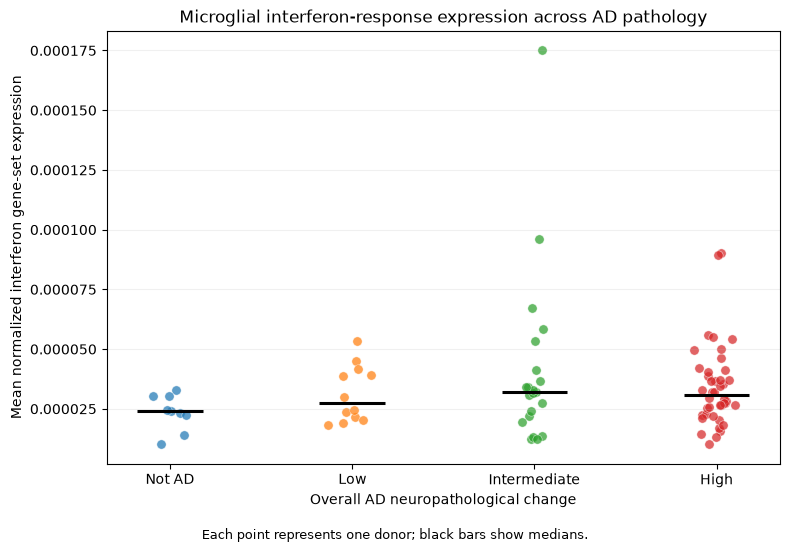

Saved: sea_ad_outputs/figures/interferon_program_across_ad_pathology.png


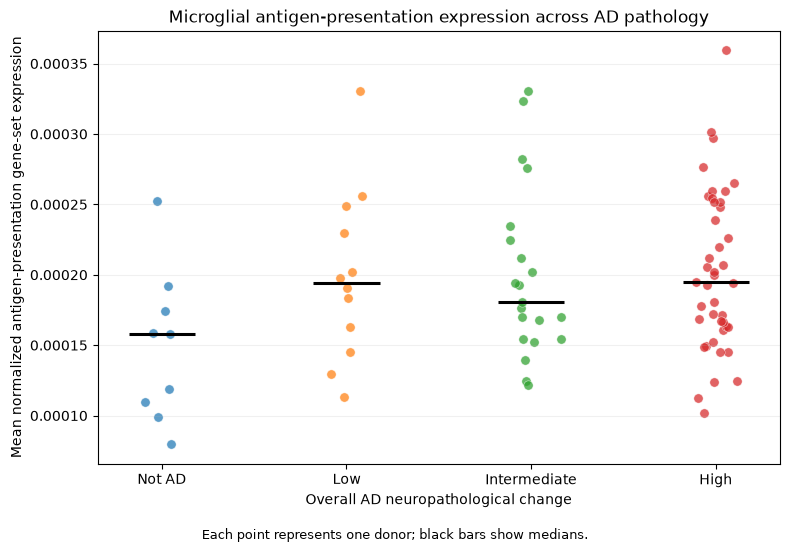

Saved: sea_ad_outputs/figures/antigen_presentation_across_ad_pathology.png


In [20]:
ADNC_ORDER = ["Not AD", "Low", "Intermediate", "High"]
ADNC_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]


def plot_four_level(outcome, y_label, title, file_name, seed):
    rng = np.random.default_rng(seed)
    fig, ax = plt.subplots(figsize=(8, 5.5))
    for position, (group, color) in enumerate(zip(ADNC_ORDER, ADNC_COLORS)):
        values = donor_results.loc[
            donor_results["Overall AD neuropathological Change"] == group, outcome
        ].to_numpy()
        jitter = rng.normal(position, 0.05, size=len(values))
        ax.scatter(jitter, values, alpha=0.72, s=45, color=color, edgecolor="white", linewidth=0.4)
        median = np.median(values)
        ax.hlines(median, position - 0.18, position + 0.18, color="black", linewidth=2.2)

    ax.set_xticks(range(len(ADNC_ORDER)), ADNC_ORDER)
    ax.set_xlabel("Overall AD neuropathological change")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.18)
    fig.text(0.5, 0.01, "Each point represents one donor; black bars show medians.", ha="center", fontsize=9)
    fig.tight_layout(rect=(0, 0.04, 1, 1))

    output_path = FIGURE_DIR / file_name
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)
    return output_path


interferon_figure = plot_four_level(
    "interferon_score",
    "Mean normalized interferon gene-set expression",
    "Microglial interferon-response expression across AD pathology",
    "interferon_program_across_ad_pathology.png",
    RANDOM_SEED,
)

antigen_figure = plot_four_level(
    "antigen_presentation_score",
    "Mean normalized antigen-presentation gene-set expression",
    "Microglial antigen-presentation expression across AD pathology",
    "antigen_presentation_across_ad_pathology.png",
    RANDOM_SEED + 1,
)


In [21]:
# Save the donor-level derived table used for all analyses.
results_path = RESULTS_DIR / "sea_ad_microglia_donor_results.csv"
output_columns = [
    "donor_id", "interferon_score", "antigen_presentation_score",
    "pathology_group", "Overall AD neuropathological Change", "Age at Death", "sex",
    "adnc_numeric", "higher_pathology", "male", "n_nuclei",
    "nuclei_10x_3prime_v3", "nuclei_10x_multiome", "multiome_fraction",
]
donor_results[output_columns].to_csv(results_path, index=False)

print("Saved:", results_path)
print("Rows:", len(donor_results))


Saved: sea_ad_outputs/results/sea_ad_microglia_donor_results.csv
Rows: 84


## Interpretation

Higher-pathology donors had modestly higher mean normalized interferon and antigen-presentation gene-set expression, but neither primary two-sided Mann–Whitney comparison was statistically significant (interferon: U = 520, p = 0.145, Cliff's delta = -0.214; antigen presentation: U = 509, p = 0.116, Cliff's delta = -0.231). Because lower pathology was supplied first, the negative deltas indicate a tendency toward higher values in the higher-pathology group.

The four-level ordinal analyses were also not statistically significant (interferon: Spearman rho = 0.145, p = 0.187; antigen presentation: rho = 0.184, p = 0.094). Age and sex distributions were similar between the exploratory binary groups.

In age- and sex-adjusted HC3 models, higher pathology had a positive interferon coefficient (8.96e-06, p = 0.031, 95% CI 8.20e-07 to 1.71e-05), whereas the antigen-presentation coefficient was not statistically significant (2.31e-05, p = 0.145). Adding donor-level multiome fraction produced similar pathology coefficients, and assay composition itself was not clearly associated with either outcome. Requiring at least 200 nuclei retained 77 donors; the nonparametric and ordinal results remained non-significant, while the adjusted interferon coefficient remained positive. Thus, one exploratory adjusted-model result should not outweigh the non-significant primary and ordinal analyses.

Important limitations include strong skewness of interferon-model residuals, sensitivity to model specification and influential donors, multiple related tests without multiplicity adjustment, unequal pathology-group sizes (21 lower versus 63 higher), assay mixing within some donors, an analyst-defined pathology dichotomy, simple unweighted gene averages rather than validated module scores, incomplete adjustment for technical and biological covariates, and the observational cross-sectional design. Association does not establish causation or a novel Alzheimer's disease mechanism.


## Fresh-run checks and cleanup

The final cell confirms the expected cohort, outputs, and connection cleanup. A manual metadata upload is not required.


In [22]:
assert len(donor_results) == 84
assert adata_norm.n_obs == 38905
assert adata_norm.n_vars == 20
assert donor_results["pathology_group"].value_counts().to_dict() == {
    "Higher pathology": 63,
    "Lower pathology": 21,
}
assert results_path.exists()
assert interferon_figure.exists()
assert antigen_figure.exists()

census.close()

print("Fresh-run checks passed.")
print("Census connection closed.")
print("No manual upload was required.")
print("Generated files:")
print(" -", results_path)
print(" -", interferon_figure)
print(" -", antigen_figure)


Fresh-run checks passed.
Census connection closed.
No manual upload was required.
Generated files:


 - sea_ad_outputs/results/sea_ad_microglia_donor_results.csv
 - sea_ad_outputs/figures/interferon_program_across_ad_pathology.png
 - sea_ad_outputs/figures/antigen_presentation_across_ad_pathology.png
